# AI for Radiologic Image Tasks: Detection

This notebook presents an educational workflow for object detection in chest radiographs. It uses the Montgomery dataset and converts the available lung masks into bounding-box annotations suitable for model development.

The objective is to localize the left and right lung fields. In contrast to image-level classification, the output includes the spatial extent of each target structure.

The main steps are:

1. Build an index linking each chest radiograph to its left and right lung masks.
2. Convert the lung masks into bounding boxes and inspect the derived annotations.
3. Create stratified train/validation/test splits from the Montgomery dataset.
4. Export the images and normalized bounding-box labels in YOLO format and create the dataset configuration.
5. Fine-tune a compact pretrained YOLO model to localize the lung fields.
6. Evaluate the trained detector on the held-out test split using precision, recall, and mean average precision.
7. Compare predicted and reference boxes to inspect localization quality and confidence scores.
8. Review the training curves to understand how model performance changes during optimization.

### Task at a glance

Chest X-ray + lung masks → Derive boxes → Export YOLO data → Train and validate → Lung boxes + confidence scores → Test → Inspect errors

> **For beginners:** only the first two setup cells are collapsed and can be run without editing. The remaining code stays visible so you can follow the implementation. ✏️ Control panels contain the safest settings to experiment with. Definitions of technical terms and solutions to common errors are available in the project README.

The goal is not to build a production-ready medical AI system or detect tuberculosis-related abnormalities. Instead, the notebook demonstrates the core object-detection workflow: derive bounding boxes from spatial annotations, preserve image-box correspondence, train a detector, and evaluate how accurately it localizes the target anatomy.

> **Google Colab quick start:** open this notebook in Colab, select **Runtime → Change runtime type → T4 GPU** (recommended for training), then choose **Runtime → Run all**. The setup cell installs missing libraries and downloads the public dataset automatically; no manual uploads or path edits are needed.


## 0. One-click setup

Run the next cell exactly as it is. It automatically installs any missing libraries, downloads the public dataset(s) into the current runtime, and reuses them if you run the cell again. In Colab, choose a GPU before running all cells for a much faster training run.

The downloaded data and model results live only for this Colab session unless you explicitly save them elsewhere.


In [1]:
#@title Setup — install dependencies and load data
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

def install(packages):
    """Install the small set of extra libraries used by this notebook."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])

PACKAGES = ["datasets", "ultralytics", "opencv-python-headless", "pyyaml"]
install(PACKAGES)

from datasets import Image as HFImage, load_dataset

DATASET_ID = "Famatsu123/montgomery-shenzhen-tuberculosis-cxr"
ds = load_dataset(
    DATASET_ID,
    data_files={"montgomery": "MontgomerySet.zip"},
).cast_column("image", HFImage(decode=False))
HF_IMAGE_DECODER = HFImage()


/home/felipe/miniconda3/envs/esr-segmentation-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating montgomery split: 555 examples [00:00, 21389.68 examples/s]


In [2]:
#@title Imports and runtime configuration
import random
import shutil
import warnings

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from ultralytics import YOLO
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["image.cmap"] = "gray"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

assert "montgomery" in ds, f"Unexpected dataset splits: {list(ds)}"

YOLO_DATASET_DIR = RESULTS_DIR / "montgomery_lung_yolo"
DATA_YAML_PATH = YOLO_DATASET_DIR / "montgomery_lung.yaml"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {DEVICE}")
print("Dataset is ready. Re-running this cell reuses the Hugging Face cache.")


Using compute device: cuda
Dataset is ready. Re-running this cell reuses the Hugging Face cache.


## 1. Build Image And Mask Index

The Montgomery dataset stores lung masks separately from the X-ray images. This section builds a table where each row links one radiograph to its left-lung mask, right-lung mask, and disease label.

The disease label is retained only as metadata for stratified splitting. It is not the detection target; the model is trained to localize lung fields rather than classify normal and abnormal studies.

**What are we doing?** Matching each radiograph with two mask files. **Why?** A box can only be derived when the image and its spatial annotations correspond. **Expected result:** 138 complete image/mask records with normal and abnormal cases represented.

In [3]:
# Build the image and mask index
def disease_label_from_id(image_id: str) -> int:
    return int(image_id.rsplit("_", 1)[-1])


def build_montgomery_index() -> pd.DataFrame:
    files_by_id = {}
    for hf_index, image_record in enumerate(ds["montgomery"]["image"]):
        archive_path = image_record["path"].replace("\\", "/")
        if not archive_path.split("::", 1)[0].lower().endswith(".png"):
            continue
        image_id = Path(archive_path.split("::", 1)[0]).stem
        if "/CXR_png/" in archive_path:
            kind = "image_index"
        elif "/leftMask/" in archive_path:
            kind = "left_mask_index"
        elif "/rightMask/" in archive_path:
            kind = "right_mask_index"
        else:
            continue
        files_by_id.setdefault(image_id, {})[kind] = hf_index

    rows = []
    required = {"image_index", "left_mask_index", "right_mask_index"}
    for image_id, file_indices in sorted(files_by_id.items()):
        if not required <= set(file_indices):
            continue
        rows.append({
            "ImageId": image_id,
            **file_indices,
            "disease_label": disease_label_from_id(image_id),
        })
    return pd.DataFrame(rows)


images_df = build_montgomery_index()
assert not images_df.empty, "No complete image/left-mask/right-mask triplets found."
print(f"Complete image/mask pairs found for YOLO detection: {len(images_df):,}")
print("Disease-label counts kept only as descriptive metadata:")
images_df["disease_label"].value_counts().rename({0: "normal", 1: "abnormal"})


Complete image/mask pairs found for YOLO detection: 138
Disease-label counts kept only as descriptive metadata:


disease_label
normal      80
abnormal    58
Name: count, dtype: int64

### 👀 How to read the index result

The total reports complete image/left-mask/right-mask triplets. The label counts describe the source dataset only. No model has been trained and no detection metric has been calculated yet.

## 2. Convert Masks To Boxes

The original Montgomery annotations are segmentation masks. For object detection, each left- and right-lung mask is converted into the smallest rectangle containing the annotated pixels.

Each image therefore has two target boxes, one for each lung. Both boxes represent the same anatomical class because the objective is localization rather than side classification.

**What are we doing?** Drawing the smallest rectangle around the positive pixels in each mask. **Why?** YOLO learns from boxes rather than pixel masks. **Expected result:** two lung boxes per image.

In [4]:
# Convert masks to boxes
def decode_hf_image(hf_index: int):
    image_record = ds["montgomery"][int(hf_index)]["image"]
    return HF_IMAGE_DECODER.decode_example(image_record)


def read_hf_grayscale(hf_index: int) -> np.ndarray:
    return np.asarray(decode_hf_image(hf_index).convert("L"))


def normalize_percentile(image: np.ndarray, lower: float = 1, upper: float = 99, eps: float = 1e-7) -> np.ndarray:
    image = image.astype(np.float32)
    lo, hi = np.percentile(image, [lower, upper])
    image = np.clip(image, lo, hi)
    return ((image - lo) / (hi - lo + eps)).astype(np.float32)


def mask_to_box(mask: np.ndarray) -> list[float] | None:
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x_min = float(xs.min())
    y_min = float(ys.min())
    x_max = float(xs.max() + 1)
    y_max = float(ys.max() + 1)
    return [x_min, y_min, x_max, y_max]


def lung_boxes(row: pd.Series) -> np.ndarray:
    boxes = []
    for mask_index in [row.left_mask_index, row.right_mask_index]:
        box = mask_to_box(read_hf_grayscale(mask_index))
        if box is not None:
            boxes.append(box)
    return np.array(boxes, dtype=np.float32)


def image_and_boxes(image_id: str) -> tuple[np.ndarray, np.ndarray]:
    row = images_df.loc[images_df["ImageId"] == image_id].iloc[0]
    image = read_hf_grayscale(row.image_index)
    boxes = lung_boxes(row)
    return image, boxes


In [5]:
box_rows = []
for row in images_df.itertuples(index=False):
    boxes = lung_boxes(pd.Series(row._asdict()))
    box_rows.append({
        "ImageId": row.ImageId,
        "boxes": boxes,
        "n_boxes": len(boxes),
    })

boxes_df = images_df.merge(pd.DataFrame(box_rows), on="ImageId")
assert (boxes_df["n_boxes"] == 2).all(), "Each Montgomery image should have two lung boxes."
print("First mask-derived box records; n_boxes should be 2 for paired lung boxes:")
boxes_df[["ImageId", "n_boxes", "disease_label"]].head()


First mask-derived box records; n_boxes should be 2 for paired lung boxes:


,ImageId,n_boxes,disease_label
0,MCUCXR_0001_0,2,0
1,MCUCXR_0002_0,2,0
2,MCUCXR_0003_0,2,0
3,MCUCXR_0004_0,2,0
4,MCUCXR_0005_0,2,0


Random sample selected for box-overlay sanity check: MCUCXR_0150_1
Original grayscale image shape before YOLO resizing: (4892, 4020)
Mask-derived lung boxes in original pixel coordinates:\n[[        174         318        1675        3630]
 [       1970         315        3494        3259]]


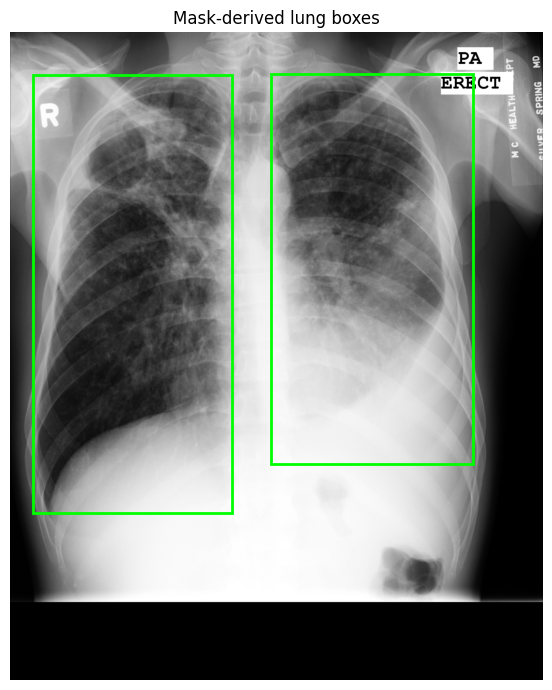

In [6]:
# Draw bounding boxes
def draw_boxes(ax, boxes, color="lime", linewidth=2, labels=None, scores=None):
    for i, box in enumerate(boxes):
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=linewidth,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)
        if labels is not None or scores is not None:
            label = labels[i] if labels is not None else "box"
            score = f" {scores[i]:.2f}" if scores is not None else ""
            ax.text(x_min, y_min, f"{label}{score}", color=color, fontsize=9, va="bottom")


sample_row = boxes_df.sample(1, random_state=SEED).iloc[0]
sample_image, sample_boxes = image_and_boxes(sample_row.ImageId)

print(f"Random sample selected for box-overlay sanity check: {sample_row.ImageId}")
print(f"Original grayscale image shape before YOLO resizing: {sample_image.shape}")
print(f"Mask-derived lung boxes in original pixel coordinates:\\n{sample_boxes}")

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(normalize_percentile(sample_image), cmap="gray")
draw_boxes(ax, sample_boxes)
ax.set_title("Mask-derived lung boxes")
ax.axis("off")
plt.tight_layout()


,x_min,y_min,x_max,y_max,class_name
0,174.0,318.0,1675.0,3630.0,lung
1,1970.0,315.0,3494.0,3259.0,lung


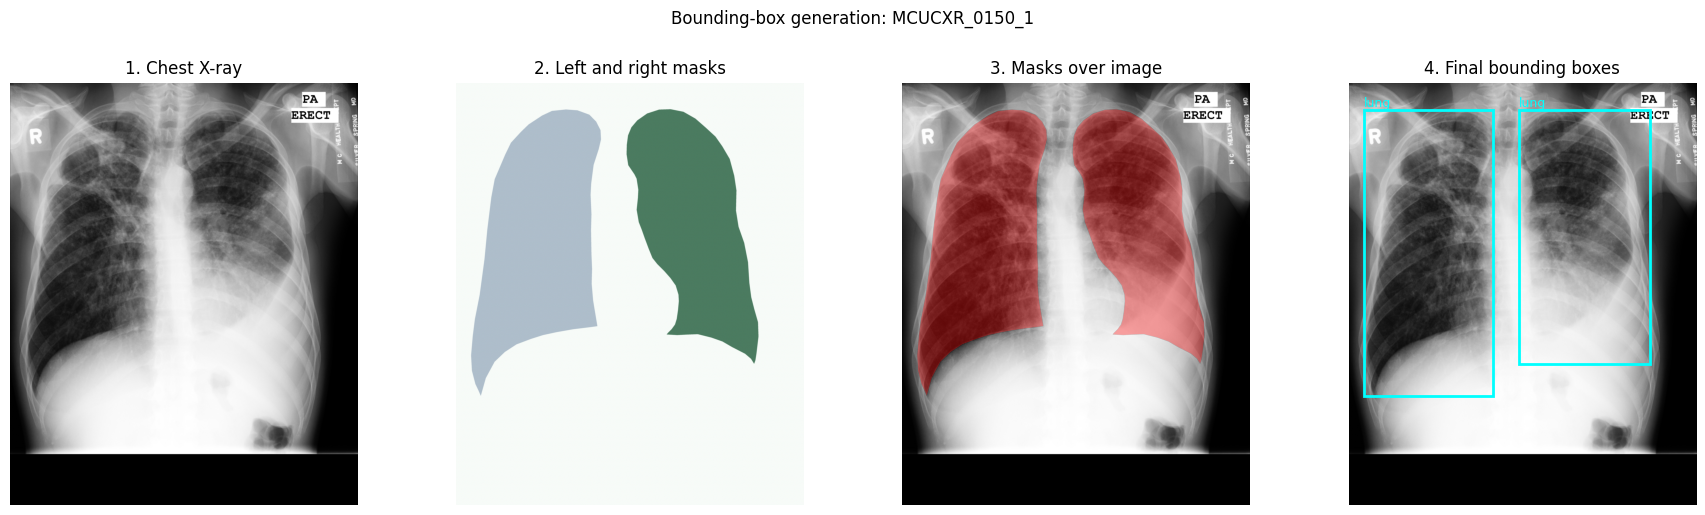

In [7]:
step_row = boxes_df.sample(1, random_state=SEED).iloc[0]
step_metadata = images_df.loc[images_df["ImageId"] == step_row.ImageId].iloc[0]

step_image = read_hf_grayscale(step_metadata.image_index)
left_mask = read_hf_grayscale(step_metadata.left_mask_index) > 0
right_mask = read_hf_grayscale(step_metadata.right_mask_index) > 0
combined_mask = left_mask | right_mask
step_boxes = lung_boxes(step_metadata)

display_image = normalize_percentile(step_image)
mask_overlay = np.ma.masked_where(~combined_mask, combined_mask)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(display_image, cmap="gray")
axes[0].set_title("1. Chest X-ray")

axes[1].imshow(left_mask, cmap="Blues")
axes[1].imshow(right_mask, cmap="Greens", alpha=0.7)
axes[1].set_title("2. Left and right masks")

axes[2].imshow(display_image, cmap="gray")
axes[2].imshow(mask_overlay, cmap="autumn", alpha=0.35)
axes[2].set_title("3. Masks over image")

axes[3].imshow(display_image, cmap="gray")
draw_boxes(axes[3], step_boxes, color="cyan", linewidth=2, labels=["lung", "lung"])
axes[3].set_title("4. Final bounding boxes")

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Bounding-box generation: {step_row.ImageId}", y=1.02)
plt.tight_layout()

pd.DataFrame(step_boxes, columns=["x_min", "y_min", "x_max", "y_max"]).assign(class_name="lung")


### 👀 How to read the annotation figures

The four-panel figure follows one case from radiograph to masks, overlay, and final boxes. A box should enclose its lung without being shifted to unrelated anatomy. The coordinates table uses original image pixels: `(x_min, y_min)` is the upper-left corner and `(x_max, y_max)` is the lower-right corner.

## 3. Train/Validation/Test Split

The dataset is divided into training, validation, and test subsets. The training set is used to update the model weights, the validation set is used during training to monitor performance, and the test set is kept aside for the final evaluation.

We keep the same stratified split idea as the original detection notebook. The disease labels are not target classes here; they only keep the split balanced across normal and abnormal studies.

**What are we doing?** Creating non-overlapping groups for fitting, model selection, and final evaluation. **Why?** Test images must remain unseen until the detector is finalized. **Expected result:** about 70%/15%/15% of images with similar abnormal fractions.

In [8]:
# Create stratified splits
def stratified_image_split(
    df: pd.DataFrame,
    valid_fraction: float = 0.15,
    test_fraction: float = 0.15,
    seed: int = SEED,
):
    if valid_fraction <= 0 or test_fraction <= 0 or valid_fraction + test_fraction >= 1:
        raise ValueError("valid_fraction and test_fraction must be positive and sum to less than 1.")

    rng = np.random.default_rng(seed)
    train_ids, valid_ids, test_ids = [], [], []
    for _, group in df.groupby("disease_label"):
        ids = group["ImageId"].to_numpy().copy()
        rng.shuffle(ids)
        n_valid = max(1, int(round(len(ids) * valid_fraction)))
        n_test = max(1, int(round(len(ids) * test_fraction)))
        if n_valid + n_test >= len(ids):
            raise ValueError("Not enough images in each class to create train, validation, and test splits.")
        valid_ids.extend(ids[:n_valid])
        test_ids.extend(ids[n_valid:n_valid + n_test])
        train_ids.extend(ids[n_valid + n_test:])

    train_ids = np.array(train_ids)
    valid_ids = np.array(valid_ids)
    test_ids = np.array(test_ids)
    rng.shuffle(train_ids)
    rng.shuffle(valid_ids)
    rng.shuffle(test_ids)
    return train_ids, valid_ids, test_ids


train_ids, valid_ids, test_ids = stratified_image_split(boxes_df)
label_lookup = boxes_df.set_index("ImageId")["disease_label"]
print("Stratified train/validation/test split size summary:")
pd.DataFrame({
    "split": ["all", "train", "valid", "test"],
    "images": [len(boxes_df), len(train_ids), len(valid_ids), len(test_ids)],
    "abnormal_fraction": [
        boxes_df["disease_label"].mean(),
        label_lookup.loc[train_ids].mean(),
        label_lookup.loc[valid_ids].mean(),
        label_lookup.loc[test_ids].mean(),
    ],
})


Stratified train/validation/test split size summary:


,split,images,abnormal_fraction
0,all,138,0.420290
1,train,96,0.416667
2,valid,21,0.428571
3,test,21,0.428571


### 👀 How to read the split table

The `images` column gives the number of radiographs in each group. Similar `abnormal_fraction` values confirm stratification, but abnormal/normal is still not the detection target.

## 4. Prepare the Detection Dataset

The detection framework expects a predefined folder structure with separate image and annotation directories for each subset. This section prepares the images and writes one annotation file per image.

Each annotation records a class identifier and the normalized center coordinates, width, and height of a bounding box. Normalized coordinates preserve the relative spatial location of the target across images of different dimensions.

**What are we doing?** Copying each split into YOLO's folder layout and writing one text label file per image. **Why?** The training framework needs a predictable data organization. **Expected result:** two exported boxes per image and a YAML file describing the splits.

In [9]:
# Export the YOLO dataset
def xyxy_to_yolo_line(box: np.ndarray, image_width: int, image_height: int, class_id: int = 0) -> str:
    x_min, y_min, x_max, y_max = box.astype(float)
    x_center = ((x_min + x_max) / 2) / image_width
    y_center = ((y_min + y_max) / 2) / image_height
    width = (x_max - x_min) / image_width
    height = (y_max - y_min) / image_height
    values = [class_id, x_center, y_center, width, height]
    return f"{values[0]} " + " ".join(f"{value:.8f}" for value in values[1:])


def export_split_to_yolo(split_name: str, image_ids, metadata: pd.DataFrame) -> list[dict]:
    image_out_dir = YOLO_DATASET_DIR / "images" / split_name
    label_out_dir = YOLO_DATASET_DIR / "labels" / split_name
    image_out_dir.mkdir(parents=True, exist_ok=True)
    label_out_dir.mkdir(parents=True, exist_ok=True)

    metadata_by_id = metadata.set_index("ImageId")
    records = []
    for image_id in tqdm(list(image_ids), desc=f"Exporting {split_name}"):
        row = metadata_by_id.loc[image_id]
        image = read_hf_grayscale(row.image_index)
        image_height, image_width = image.shape[:2]
        boxes = lung_boxes(row)
        if len(boxes) == 0:
            raise ValueError(f"No lung boxes found for {image_id}")

        image_out_path = image_out_dir / f"{image_id}.png"
        label_out_path = label_out_dir / f"{image_id}.txt"
        decode_hf_image(row.image_index).save(image_out_path)
        label_out_path.write_text("\n".join(xyxy_to_yolo_line(box, image_width, image_height) for box in boxes) + "\n")
        records.append({
            "split": split_name,
            "ImageId": image_id,
            "image_path": image_out_path,
            "label_path": label_out_path,
            "image_width": image_width,
            "image_height": image_height,
            "n_boxes": len(boxes),
        })
    return records


RECREATE_YOLO_DATASET = True
if RECREATE_YOLO_DATASET and YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)

export_records = []
export_records.extend(export_split_to_yolo("train", train_ids, boxes_df))
export_records.extend(export_split_to_yolo("val", valid_ids, boxes_df))
export_records.extend(export_split_to_yolo("test", test_ids, boxes_df))
export_df = pd.DataFrame(export_records)

DATA_YAML_PATH.parent.mkdir(parents=True, exist_ok=True)
data_yaml = {
    "path": str(YOLO_DATASET_DIR.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {0: "lung"},
}
DATA_YAML_PATH.write_text(yaml.safe_dump(data_yaml, sort_keys=False))

print(f"YOLO dataset YAML written to: {DATA_YAML_PATH}")
print(f"YOLO dataset root: {YOLO_DATASET_DIR.resolve()}")
export_df.groupby("split").agg(images=("ImageId", "count"), boxes=("n_boxes", "sum"))


Exporting test: 100%|██████████| 21/21 [00:46<00:00,  2.21s/it]

YOLO dataset YAML written to: results/montgomery_lung_yolo/montgomery_lung.yaml
YOLO dataset root: /home/felipe/projects/ESR_notebooks/notebooks/results/montgomery_lung_yolo


,images,boxes
split,,
test,21,42
train,96,192
val,21,42


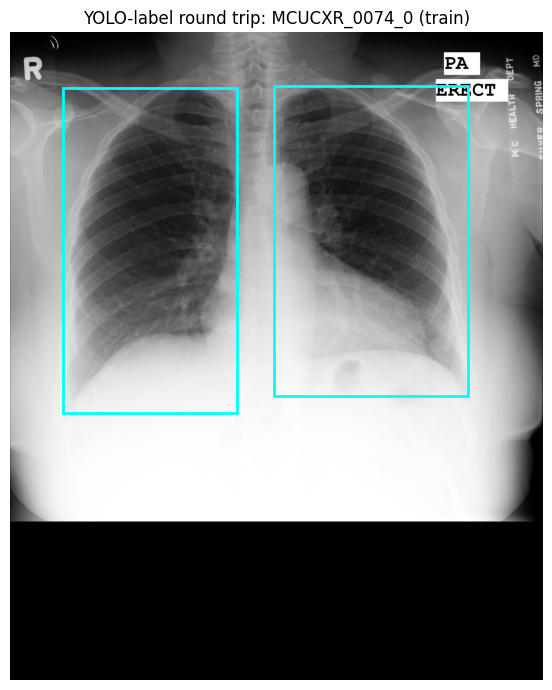

In [10]:
# Verify exported annotations
def yolo_label_file_to_xyxy(label_path: Path, image_width: int, image_height: int) -> np.ndarray:
    boxes = []
    for line in label_path.read_text().replace("\\n", "\n").splitlines():
        if not line.strip():
            continue
        class_id, x_center, y_center, width, height = map(float, line.split())
        x_center *= image_width
        y_center *= image_height
        width *= image_width
        height *= image_height
        boxes.append([
            x_center - width / 2,
            y_center - height / 2,
            x_center + width / 2,
            y_center + height / 2,
        ])
    return np.array(boxes, dtype=np.float32)


preview_record = export_df.sample(1, random_state=SEED).iloc[0]
preview_image = cv2.imread(str(preview_record.image_path), cv2.IMREAD_GRAYSCALE)
preview_boxes = yolo_label_file_to_xyxy(preview_record.label_path, preview_record.image_width, preview_record.image_height)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(normalize_percentile(preview_image), cmap="gray")
draw_boxes(ax, preview_boxes, color="cyan")
ax.set_title(f"YOLO-label round trip: {preview_record.ImageId} ({preview_record.split})")
ax.axis("off")
plt.tight_layout()


### 👀 How to read the YOLO export check

The export table should report one row per image and two boxes per image in every split. The round-trip preview converts a saved normalized label back to pixel coordinates; boxes that still align with the lungs confirm that the export preserved geometry.

## 5. Train the Detection Model

This section defines the training settings and fine-tunes a pretrained detector for a single anatomical class.

A compact model is used to support efficient teaching and rapid iteration. More computationally intensive configurations can be explored after the basic workflow has been established.

**What are we doing?** Fine-tuning pretrained YOLO weights on the lung boxes. **Why?** Transfer learning is more practical than learning visual features from scratch on 138 images. **Expected result:** losses generally decrease and validation detection metrics improve.

> ✏️ **Control panel:** `EPOCHS`, `IMAGE_SIZE`, and `BATCH_SIZE` affect runtime and memory. `CONFIDENCE_THRESHOLD` changes which predictions are kept during evaluation; it does not retrain the model.

In [11]:
# ✏️ Control panel — YOLO training and evaluation settings
YOLO_MODEL = "yolo26n.pt"

EPOCHS = 25
IMAGE_SIZE = 640
BATCH_SIZE = 8
NUM_WORKERS = 2 if IN_COLAB else 4
CONFIDENCE_THRESHOLD = 0.10
EVALUATION_IOU_THRESHOLD = 0.50

DEVICE_ARG = 0 if torch.cuda.is_available() else "cpu"
YOLO_PROJECT_DIR = RESULTS_DIR / "yolo_detection_runs"
YOLO_RUN_NAME = "yolo26n_montgomery_lung_boxes"

print(f"YOLO model: {YOLO_MODEL}")
print(f"Ultralytics dataset config: {DATA_YAML_PATH}")
print(f"Ultralytics device argument: {DEVICE_ARG}")
print(f"Approximate input tensor: [batch, channels, height, width] = [{BATCH_SIZE}, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]")
print("YOLO converts grayscale files to 3-channel batches and may pad images while preserving their box geometry.")


YOLO model: yolo26n.pt
Ultralytics dataset config: results/montgomery_lung_yolo/montgomery_lung.yaml
Ultralytics device argument: 0
Approximate input tensor: [batch, channels, height, width] = [8, 3, 640, 640]
YOLO converts grayscale files to 3-channel batches and may pad images while preserving their box geometry.


In [12]:
# Train YOLO
model = YOLO(YOLO_MODEL)
train_results = model.train(
    data=str(DATA_YAML_PATH.resolve()),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE_ARG,
    project=str(YOLO_PROJECT_DIR.resolve()),
    name=YOLO_RUN_NAME,
    exist_ok=True,
    seed=SEED,
    workers=NUM_WORKERS,
    plots=True,
    cos_lr=True,
    single_cls=True,
)


New https://pypi.org/project/ultralytics/8.4.102 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.71 🚀 Python-3.11.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060, 7800MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/felipe/projects/ESR_notebooks/notebooks/results/montgomery_lung_yolo/montgomery_lung.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

### 👀 How to read the training run

YOLO reports box-related losses and validation metrics by epoch. Lower losses are favorable, while higher precision, recall, and mAP are favorable. After training, the validation-selected model remains available in memory for evaluation.

## 6. Test Evaluation

After training, the validation-selected model remains in memory and is used directly for final evaluation on the held-out test set.

This section evaluates that in-memory model on the held-out test split from the generated YAML. The test split is used here because it was not used to fit the model.

### Detection metrics by picture

```text
Reference box:  ┌────────────┐
                │     ┌──────┼────┐  Predicted box
                │     │shared│    │
                └─────┼──────┘    │
                      └───────────┘

IoU = overlapping area ÷ total area covered by both boxes
```

- **True positive:** a predicted box matches a reference box closely enough at the chosen IoU threshold.
- **False positive:** a retained predicted box has no adequate reference match.
- **False negative:** a reference lung has no adequate predicted match.
- **Precision:** among kept predictions, how many were matched? **Recall:** among reference lungs, how many were found?
- **mAP50:** summarizes precision and recall using IoU 0.50. **mAP50–95:** averages over increasingly strict overlap requirements and is usually lower.


In [13]:
# Evaluate the trained in-memory model on the held-out test split
RUN_DIR = Path(model.trainer.save_dir)

test_metrics = model.val(
    data=str(DATA_YAML_PATH),
    split="test",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE_ARG,
    conf=CONFIDENCE_THRESHOLD,
    iou=EVALUATION_IOU_THRESHOLD,
    plots=False,
)

print("Evaluated the validation-selected model retained in memory after training.")
print(f"Evaluation confidence threshold: {CONFIDENCE_THRESHOLD:.2f}; IoU threshold: {EVALUATION_IOU_THRESHOLD:.2f}")
metric_names = {
    "metrics/precision(B)": "precision",
    "metrics/recall(B)": "recall",
    "metrics/mAP50(B)": "mAP50",
    "metrics/mAP50-95(B)": "mAP50-95",
}
test_summary = pd.DataFrame([{
    display_name: float(test_metrics.results_dict[result_key])
    for result_key, display_name in metric_names.items()
}])
display(test_summary.round(3))


Ultralytics 8.4.71 🚀 Python-3.11.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060, 7800MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5939.0±2429.3 MB/s, size: 4293.1 KB)
val: Scanning /home/felipe/projects/ESR_notebooks/notebooks/results/montgomery_lung_yolo/labels/test... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 653.5it/s 0.0s
val: New cache created: /home/felipe/projects/ESR_notebooks/notebooks/results/montgomery_lung_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.2s0.5ss
                   all         21         42      0.973      0.848      0.956      0.863
Speed: 0.5ms preprocess, 22.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Evaluated the validation-selected model retained in memory after training.
Evaluation confidence threshold: 0.10; IoU threshold: 0.50


,precision,recall,mAP50,mAP50-95
0,0.973,0.848,0.956,0.863


### 👀 How to read the held-out metrics

Higher precision, recall, mAP50, and mAP50–95 are favorable. Read precision and recall together: a detector can avoid false alarms by predicting very few boxes yet miss lungs, or find nearly every lung while producing duplicates. The printed confidence and IoU thresholds are part of the result and should be reported with the metrics. This small held-out split does not establish clinical performance.

## 7. Preview Predictions

This section provides a visual assessment of model behavior on held-out images. For each selected test image, the reference boxes are compared with the predicted boxes.

The number of predicted boxes is not forced to be two. A well-performing model should usually detect both lungs, but it may return one box if one lung is missed, or more than two boxes if there are duplicate detections. The confidence threshold controls which predictions are displayed. The held-out evaluation reports precision, recall, mAP at IoU 0.50, and mAP averaged across IoU thresholds from 0.50 to 0.95; it uses the confidence and IoU thresholds printed in the preceding cell.

**Expected result:** green reference boxes and red predicted boxes should cover similar lung regions.

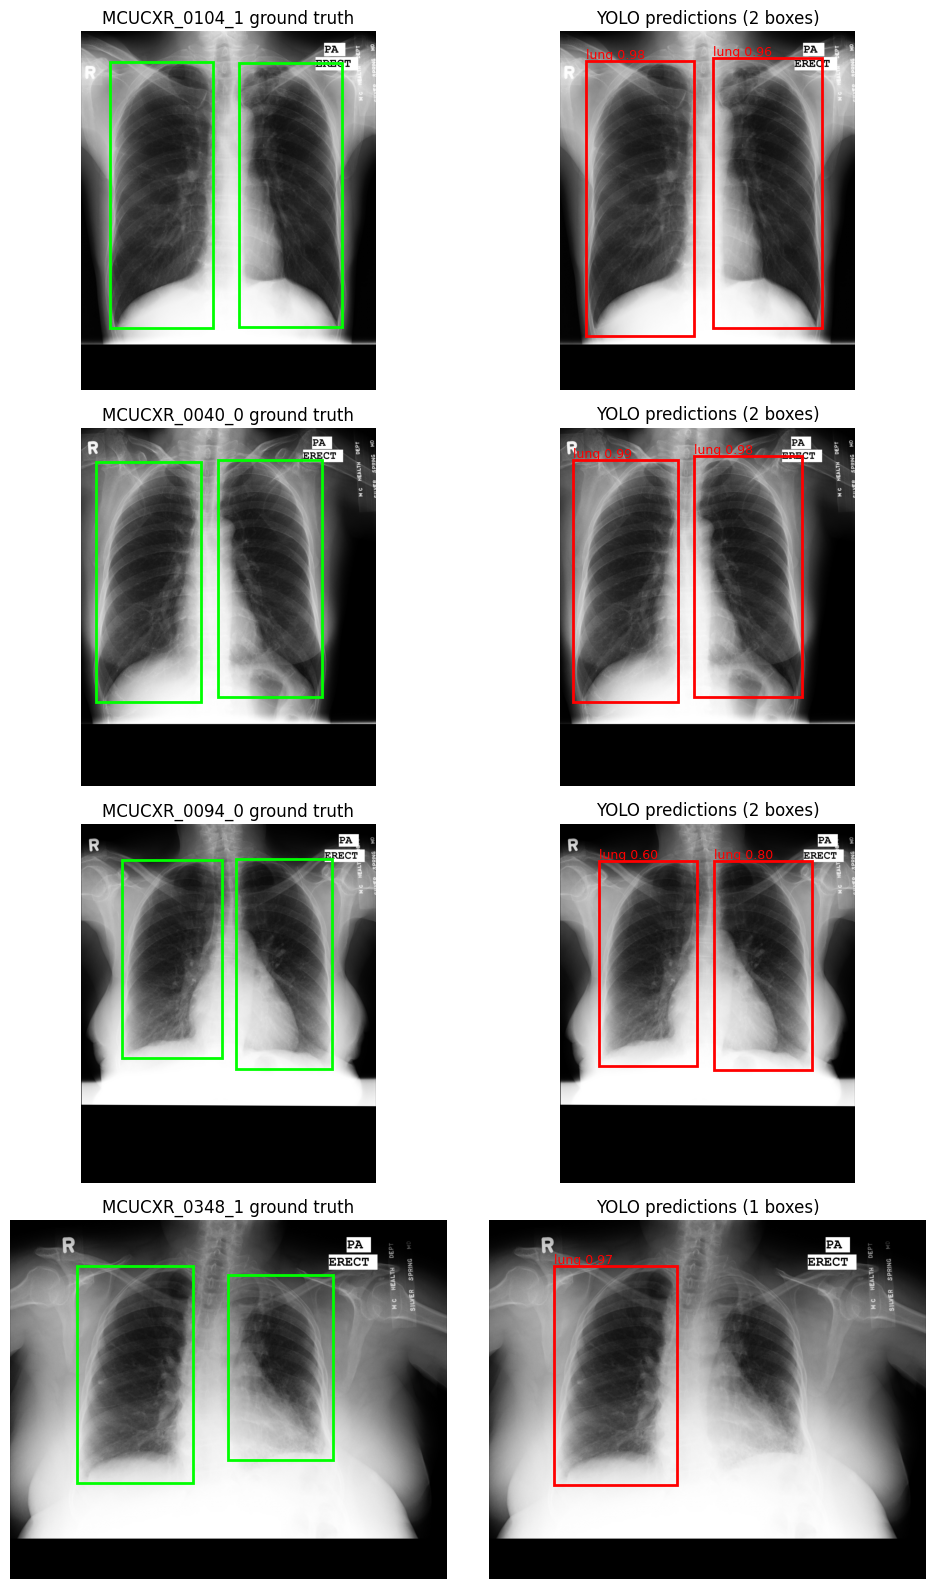

In [14]:
# Preview held-out predictions
def result_boxes_xyxy(result) -> tuple[np.ndarray, np.ndarray]:
    if result.boxes is None or len(result.boxes) == 0:
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32)
    boxes = result.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
    scores = result.boxes.conf.detach().cpu().numpy().astype(np.float32)
    return boxes, scores


preview_records = export_df.loc[export_df["split"] == "test"].head(4).reset_index(drop=True)
preview_paths = preview_records["image_path"].tolist()
results = model.predict(
    source=[str(path) for path in preview_paths],
    imgsz=IMAGE_SIZE,
    conf=CONFIDENCE_THRESHOLD,
    device=DEVICE_ARG,
    save=False,
    verbose=False,
)

n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
if n == 1:
    axes = axes[None, :]

for i, result in enumerate(results):
    record = preview_records.iloc[i]
    image_path = Path(record.image_path)
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    true_boxes = yolo_label_file_to_xyxy(record.label_path, record.image_width, record.image_height)
    pred_boxes, pred_scores = result_boxes_xyxy(result)

    axes[i, 0].imshow(normalize_percentile(image), cmap="gray")
    draw_boxes(axes[i, 0], true_boxes, color="lime")
    axes[i, 0].set_title(f"{record.ImageId} ground truth")

    axes[i, 1].imshow(normalize_percentile(image), cmap="gray")
    draw_boxes(axes[i, 1], pred_boxes, color="red", labels=["lung"] * len(pred_boxes), scores=pred_scores)
    axes[i, 1].set_title(f"YOLO predictions ({len(pred_boxes)} boxes)")

    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()


### 👀 How to read the prediction comparison

Compare each ground-truth panel with the prediction beside it. Two red boxes with high confidence are not sufficient if their locations disagree with the green references. Conversely, a slightly imperfect box may still count as a match depending on the IoU threshold. The examples explain failure modes that aggregate mAP cannot show.

## 8. Training Curves

Training metrics are recorded during optimization and summarized as performance and loss curves. These curves help assess whether the model improved during training and whether optimization was stable.

The final cell plots the most useful detection metrics and losses when they are available. In an educational setting, these plots are useful for connecting the training process to measurable model performance.

Rising validation mAP suggests improving localization. Falling training losses with flat or worsening validation metrics can indicate overfitting. Short-term fluctuations are common with this small dataset, so interpret the broad trend rather than one epoch.

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
20,21,70.7986,0.51313,2.62970,0.01211,0.97596,0.96692,0.99040,0.87742,0.54246,2.60960,0.01138,0.000209,0.000209,0.000209
21,22,72.7096,0.52431,2.62120,0.01158,0.94081,0.95238,0.98946,0.88650,0.52392,2.59347,0.01095,0.000142,0.000142,0.000142
22,23,75.2115,0.49096,2.60394,0.01141,0.93125,0.95238,0.98747,0.89223,0.50141,2.56590,0.01072,0.000090,0.000090,0.000090
23,24,77.0549,0.49985,2.59309,0.01129,0.93031,0.95238,0.98861,0.89769,0.49317,2.55555,0.01060,0.000051,0.000051,0.000051
24,25,78.7553,0.43972,2.52444,0.00976,0.93564,0.95238,0.98861,0.89687,0.47211,2.54193,0.01023,0.000028,0.000028,0.000028


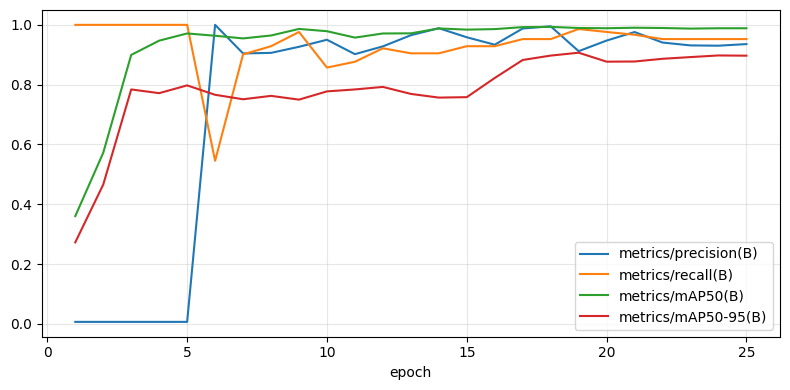

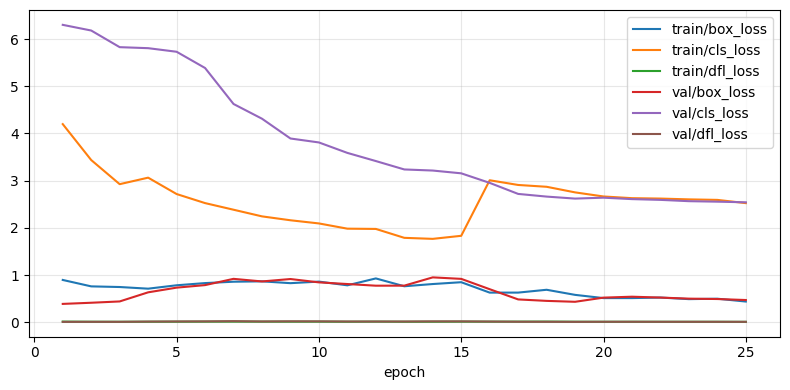

In [15]:
RESULTS_CSV = RUN_DIR / "results.csv"
assert RESULTS_CSV.exists(), f"Training results CSV not found: {RESULTS_CSV}"

history_df = pd.read_csv(RESULTS_CSV)
history_df.columns = [column.strip() for column in history_df.columns]
display(history_df.tail())

metric_columns = [
    column for column in history_df.columns
    if column in {"metrics/mAP50(B)", "metrics/mAP50-95(B)", "metrics/precision(B)", "metrics/recall(B)"}
]
loss_columns = [column for column in history_df.columns if column.endswith("loss")]

if metric_columns:
    history_df.plot(x="epoch", y=metric_columns, figsize=(8, 4))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

if loss_columns:
    history_df.plot(x="epoch", y=loss_columns, figsize=(8, 4))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()


### 👀 How to read the training curves

Metric curves are better when they move upward; loss curves are generally better when they move downward. The best validation epoch may occur before the last epoch, which is why the validation-selected in-memory model is evaluated. These curves diagnose optimization behavior, not clinical validity.

## 🧪 Try it yourself

- **Confidence threshold:** try `0.05`, `0.25`, and `0.50`, then rerun evaluation and previews. Lower values usually show more boxes, including more false positives; higher values can miss lungs. No retraining is required.
- **Shorter training:** reduce `EPOCHS` for a faster demonstration. Expect less opportunity to learn and potentially lower or less stable validation mAP.
- **Batch size:** lower `BATCH_SIZE` if GPU memory is exhausted. This changes training behavior slightly, so do not compare runs as if batch size were irrelevant.
- **Different example:** sample different rows from the test export for the preview. This changes only the cases displayed, not the metrics.

**Takeaway:** detection predicts approximate lung locations with boxes and confidence scores. It does not delineate precise lung boundaries and does not localize TB lesions.
